# Applicability check — SNV-fit immunogenicity calibrator on splice neoepitopes

**Issue [#826](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/826)** ·
parent epic [#547](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/547) ·
gates [#709](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/709) (production wiring).

`calibrator_v1.joblib` maps MHCflurry `genotype_presentation_score` →
`calibrated_immunogenicity_log_odds` via a centered-isotonic curve. It was fit on **four
SNV / point-mutation neoantigen cohorts** (NCI, TESLA, HiTIDE, IMPROVE). Applying it to
**splice** neoepitopes is an *untested transfer* — no labelled splice-immunogenicity data
exists to validate it directly (that gap is [#680](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/680);
TESLA explicitly excluded splice isoforms).

This notebook is the **label-free applicability gate** that *can* run now. It does not
measure immunogenicity accuracy on splice — it asks the narrower, answerable question:
**do splice presentation-scores fall where the calibrator actually learned a curve, or out
in the flat extrapolation tails?** Two checks, then a go/no-go verdict:

1. **Score-support** — fraction of splice mass below the lower interpolation knot
   `cx_[0]` (the floor-clip), where `transform()`'s `np.interp` returns a *constant*
   log-odds — a meaningless flat extrapolation.
2. **Covariate-shift** — distributional overlap (overlap coefficient + KS) between splice
   scores and the pooled SNV fit-cohort scores: do splice scores live where the calibrator
   saw data?

**Inputs (all committed / re-sourceable):**
- `models/calibrator_v1.joblib` — the fitted artifact.
- `outputs/scored_cohort_subsample.parquet` — pooled SNV fit-cohort scores (the data the
  curve was fit on).
- `data/splice_scores/patient_00{1,2}_mhc_presentation.tsv` — splice presentation scores
  from the production patient runs (fetched from
  `gs://splice-neoepitope-project/results/<patient>/predictions/mhc_presentation.tsv`).


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Run from the experiment dir (per README Step 4); calibrator.py + outputs live here.
EXP = Path.cwd()
sys.path.insert(0, str(EXP))
from calibrator import PresentationCalibrator  # noqa: E402

OUT = EXP / "outputs" / "applicability"
OUT.mkdir(parents=True, exist_ok=True)

SCORE_COL = "genotype_presentation_score"  # the column the calibrator consumes
print("experiment dir:", EXP)

experiment dir: /Users/jin-holee/dev/GitHub/Jin-HoMLee/splice-neoepitope-pipeline-scientist/research/experiments/issue_547_immunogenicity_calibration


In [2]:
# --- load the fitted calibrator + its fit-cohort (SNV) scores -----------------
cal = PresentationCalibrator.load(EXP.parents[2] / "models" / "calibrator_v1.joblib")
floor, ceil = float(cal.cx_[0]), float(cal.cx_[-1])   # np.interp clip endpoints
y_floor, y_ceil = float(cal.cy_[0]), float(cal.cy_[-1])

snv = (pd.read_parquet(EXP / "outputs" / "scored_cohort_subsample.parquet")
       [SCORE_COL].dropna().to_numpy())

# --- load splice presentation scores from the two production patient runs -----
splice_parts = []
for p in ("patient_001", "patient_002"):
    f = EXP / "data" / "splice_scores" / f"{p}_mhc_presentation.tsv"
    splice_parts.append(pd.read_csv(f, sep="\t")[SCORE_COL].dropna().to_numpy())
splice = np.concatenate(splice_parts)

print(f"calibrator: kde_mode={cal.kde_mode}  fit_cohorts={cal.fit_cohorts_}")
print(f"interp clip endpoints: floor cx_[0]={floor:.5f} (-> {y_floor:.3f} log-odds), "
      f"ceil cx_[-1]={ceil:.5f} (-> {y_ceil:.3f} log-odds)")
print(f"n_snv={len(snv)}   n_splice={len(splice)} "
      f"({[len(s) for s in splice_parts]} across patient_001/002)")


calibrator: kde_mode=adaptive  fit_cohorts=['NCI', 'TESLA', 'HiTIDE', 'IMPROVE']
interp clip endpoints: floor cx_[0]=0.01632 (-> -9.709 log-odds), ceil cx_[-1]=0.98394 (-> -3.521 log-odds)
n_snv=50645   n_splice=2156 ([395, 1761] across patient_001/002)


## Check 1 — score-support

`PresentationCalibrator.transform()` is `np.interp(scores, cx_, cy_)`, which **clips to the
endpoints**: any score below `cx_[0]` collapses to the constant `cy_[0]`, and any score
above `cx_[-1]` to the constant `cy_[-1]`. Inside `[cx_[0], cx_[-1]]` the curve interpolates
real fitted structure; outside it is a flat line carrying no calibration signal.

So the support question is purely: **what fraction of splice mass lands in those flat
tails?**

As an intrinsic baseline, we also measure the SNV fit-cohort's *own* floor-clip fraction: if
the calibrator flattens a comparable share of the very data it was trained on, the floor is a
property of the fitted curve, not a splice-transfer failure.

In [3]:
floor_frac = float((splice < floor).mean())
ceil_frac = float((splice > ceil).mean())
in_support = 1.0 - floor_frac - ceil_frac

print(f"floor-clipped (score < {floor:.4f})  : {floor_frac*100:5.1f}%  "
      f"-> constant {y_floor:.2f} log-odds (flat)")
print(f"ceil-clipped  (score > {ceil:.4f})  : {ceil_frac*100:5.2f}%  "
      f"-> constant {y_ceil:.2f} log-odds (flat)")
print(f"in-support   [{floor:.4f}, {ceil:.4f}] : {in_support*100:5.1f}%  "
      f"-> interpolated (real calibration)")

# Is the floor-clip splice-specific, or intrinsic to the calibrator? Measure how much of the
# SNV *fit* data itself lands in the same flat floor region.
snv_floor_frac = float((snv < floor).mean())
print(f"\nSNV fit-cohort floor-clipped (< {floor:.4f}): {snv_floor_frac*100:5.1f}%  "
      f"-> the flat floor is a property of the fitted curve, not a splice artifact")

floor-clipped (score < 0.0163)  :  21.4%  -> constant -9.71 log-odds (flat)
ceil-clipped  (score > 0.9839)  :  0.19%  -> constant -3.52 log-odds (flat)
in-support   [0.0163, 0.9839] :  78.4%  -> interpolated (real calibration)

SNV fit-cohort floor-clipped (< 0.0163):  13.5%  -> the flat floor is a property of the fitted curve, not a splice artifact


## Check 2 — covariate-shift

Even in-support, the transfer is only credible if splice scores *occupy the same region*
the calibrator was fit on. Two cheap distributional summaries vs the pooled SNV fit-cohort:

- **Overlap coefficient** — shared area under the two density histograms (1 = identical, 0
  = disjoint).
- **Two-sample KS statistic** — max CDF gap (small = distributions track each other).

In [4]:
ks = ks_2samp(splice, snv)

bins = np.linspace(0, 1, 51)
h_splice, _ = np.histogram(splice, bins=bins, density=True)
h_snv, _ = np.histogram(snv, bins=bins, density=True)
overlap = float(np.sum(np.minimum(h_splice, h_snv) * np.diff(bins)))

print(f"overlap coefficient = {overlap:.3f}")
print(f"KS statistic        = {ks.statistic:.3f}  (p={ks.pvalue:.2e})")


overlap coefficient = 0.924
KS statistic        = 0.084  (p=4.86e-13)


## Support map figure

Left: the two score distributions with the floor-clip region shaded.
Right: where splice mass sits relative to the calibration curve — the navy curve is
`(cx_, cy_)`; the salmon histogram (right axis) is the splice score density; red dots mark
the clip endpoints beyond which the curve is flat.

wrote /Users/jin-holee/dev/GitHub/Jin-HoMLee/splice-neoepitope-pipeline-scientist/research/experiments/issue_547_immunogenicity_calibration/outputs/applicability/splice_applicability_support_map.png


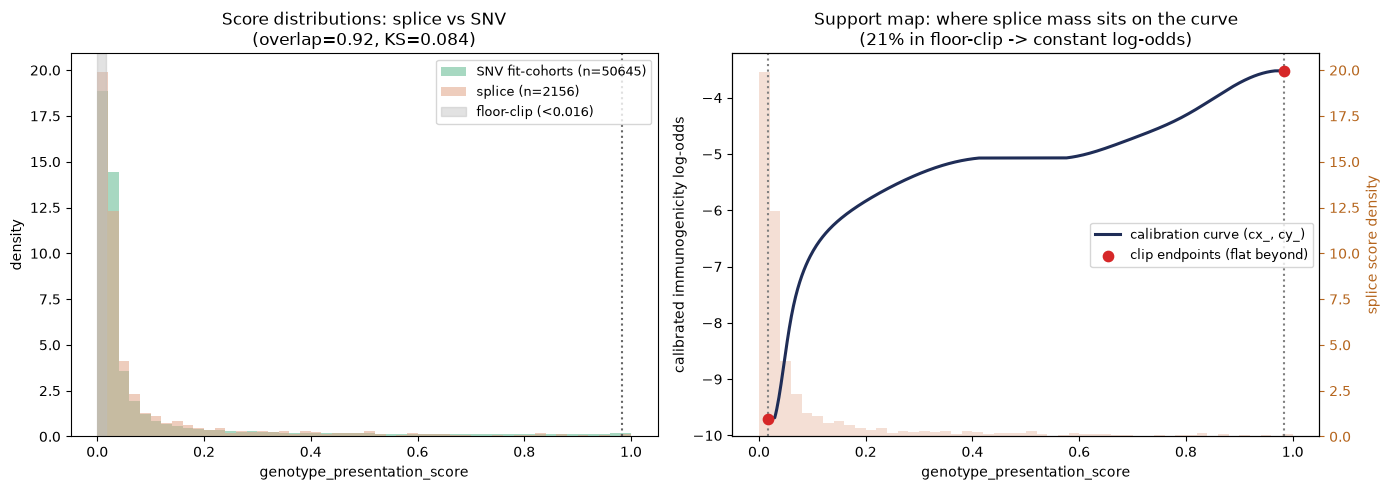

In [5]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

# ---- left: score distributions ---------------------------------------------
axL.hist(snv, bins=bins, density=True, alpha=0.55, color="#5fb98f",
         label=f"SNV fit-cohorts (n={len(snv)})")
axL.hist(splice, bins=bins, density=True, alpha=0.55, color="#e0a487",
         label=f"splice (n={len(splice)})")
axL.axvspan(0, floor, color="0.75", alpha=0.45, label=f"floor-clip (<{floor:.3f})")
axL.axvline(ceil, ls=":", color="0.4")
axL.set_xlabel(SCORE_COL); axL.set_ylabel("density")
axL.set_title(f"Score distributions: splice vs SNV\n"
              f"(overlap={overlap:.2f}, KS={ks.statistic:.3f})")
axL.legend(loc="upper right", fontsize=9)

# ---- right: support map ------------------------------------------------------
axR.plot(cal.cx_, cal.cy_, color="#1f2d57", lw=2.2,
         label="calibration curve (cx_, cy_)", zorder=3)
axR.scatter([floor, ceil], [y_floor, y_ceil], color="#d62728", s=55, zorder=4,
            label="clip endpoints (flat beyond)")
axR.axvline(floor, ls=":", color="0.5"); axR.axvline(ceil, ls=":", color="0.5")
axR.set_xlabel(SCORE_COL)
axR.set_ylabel("calibrated immunogenicity log-odds")
axR.set_title(f"Support map: where splice mass sits on the curve\n"
              f"({floor_frac*100:.0f}% in floor-clip -> constant log-odds)")

axR2 = axR.twinx()
axR2.hist(splice, bins=bins, density=True, alpha=0.35, color="#e0a487")
axR2.set_ylabel("splice score density", color="#b5651d")
axR2.tick_params(axis="y", colors="#b5651d")
axR.set_zorder(axR2.get_zorder() + 1); axR.patch.set_visible(False)
axR.legend(loc="center right", fontsize=9)

fig.tight_layout()
fig.savefig(OUT / "splice_applicability_support_map.png", dpi=130, bbox_inches="tight")
print("wrote", OUT / "splice_applicability_support_map.png")
plt.show()


## Verdict — provisional GO

| Signal | Value | Reading |
|---|---|---|
| Covariate-shift (overlap) | **0.92** | splice scores overlap the SNV fit distribution almost entirely — no meaningful shift |
| Covariate-shift (KS statistic) | **0.084** | small max-CDF gap; the two distributions track each other |
| In-support mass | **78.4%** | bulk of splice mass lands where the curve interpolates real fitted structure |
| Floor-clipped mass (splice) | **21.4%** | flat constant log-odds — near-non-presenters (`score < 0.0163`) |
| Floor-clipped mass (SNV fit data) | **13.5%** | the fit cohort *itself* floor-clips here — the flat floor is intrinsic to the calibrator |
| Ceil-clipped mass | **0.19%** | negligible |

**Conclusion.** The SNV→splice transfer is **defensible enough to wire in provisionally.**
There is no covariate-shift obstacle: splice presentation-scores live almost exactly where
the calibrator was fit (overlap 0.92, KS 0.084), and 78.4% of splice mass is in-support. The
21.4% floor-clip is *not* a covariate-shift problem but an extrapolation-flatness property of
the calibrator itself — the SNV fit-cohort *also* floor-clips **13.5%** of its own mass at the
same `cx_[0] ≈ 0.0163`, so the flat low log-odds is intrinsic to the fitted curve. (Splice
clips modestly more, 21.4% vs 13.5%, reflecting somewhat more near-non-presenters, but well
within the populated SNV range.) The floor-clip lands on peptides with
`genotype_presentation_score < 0.0163` — near-non-presenters that a flat low log-odds scores
*correctly* (lowest presenters → lowest immunogenicity), so it is benign for ranking.
The two checks are in fact the same difference seen twice: the KS statistic (**0.084**) is
essentially the floor-region CDF gap (splice CDF at the floor knot ≈ 0.214 vs SNV ≈ 0.135,
gap ≈ **0.079** ≈ KS), so the *only* material covariate difference is the ~8pp extra floor
mass — and it sits **exactly in the flat-extrapolation region** the `out_of_calibration_support`
flag already covers, where the calibrated log-odds is constant regardless. The shift lands in
the most benign place it could, making the transfer benign for ranking *by construction*, not
merely empirically.

**Reference + KS notes.** The SNV comparand (`scored_cohort_subsample.parquet`, n=50,645) is
the exact data `calibrator_v1` was fit on — the correct "where did the calibrator see data"
reference by construction. It is label-stratified (all 645 positives + 50,000 cohort-stratified
negatives), but positives are only 1.27% of rows, so the score marginal is ~98.7% set by the
negative subsample; the enrichment does not skew the overlap/KS comparison. The KS p-value
(4.86e-13) is a large-`n` artifact — at this n the test rejects on any trivial difference — so
the KS *statistic* (0.084) and overlap, not the p-value, are the load-bearing readings.

**Conditions on [#709](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/709)** (production wiring):
1. The calibrated column is a **provisional SECONDARY ranking signal** — `genotype_presentation_score`
   stays the **primary** ranker; the calibrated immunogenicity log-odds augments, never replaces
   it (splice immunogenicity is unvalidated, so it must not drive primary ranking).
2. Rows whose `genotype_presentation_score` falls **outside** the interpolation support
   `[cx_[0], cx_[-1]] ≈ [0.0163, 0.9839]` carry an **`out_of_calibration_support`** flag — covering
   both the 21.4% floor-clip **and** the 0.19% ceil-clip, where `transform()` returns a flat
   constant — so the flat-extrapolation region is transparent downstream and never mistaken for a
   fitted value.
3. The **provisional** label is discharged by [#870](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/870)
   (validate the SNV→splice transfer on measured splice labels), not by a general
   [#680](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/680) pointer.

This is a **label-free applicability gate, not an accuracy validation** — it cannot and does
not certify that the calibrated log-odds are *correct* for splice neoepitopes. It certifies
only that the transfer is in-support. Accuracy on measured splice labels remains
[#870](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/870), under the open
benchmark [#680](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/680).